## Reading and Using Evaluation Results

The evaluation results are stored and accessed through a specific data structure contained in the pickle files collected by the TarPass `collect` module. This structure is designed to make analysis more convenient: researchers can easily retrieve all sub-splits of a single metric from a global perspective, or access all available information from the perspective of an individual molecule.

This notebook aims to provide a quick and clear introduction to this data structure, helping you get started efficiently.


In [2]:
from utils.io import read_pkl
results = read_pkl('Deepblock_eval_results.pkl')

/home/sorui/anaconda3/envs/tarpass/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


After loading the `.pkl` file, the data is represented as a dictionary. Each key–value pair corresponds to a specific target, where the value stores the associated results encapsulated in a `MoleculesData` class.


In [3]:
tyk2 = results.get('TYK2')
type(tyk2)

analysis.collect_eval.MoleculesData

The `MoleculesData` class allows access to information for a specific molecule by index. Here, we take the molecule shown in Figure 4e as an example.


In [4]:
idx = 599
info = tyk2[idx]
info

{'Mol': {'rdmol': <rdkit.Chem.rdchem.Mol at 0x71c14c05ebb0>,
  'pose': <rdkit.Chem.rdchem.Mol at 0x71c14bb92570>,
  'smiles': 'Cc1cc(C)cc(Nc2ccn3ncc(C(=O)NC[C@@](C)(O)CO)c3n2)c1',
  'inchikey': 'XOPIMAUZHNUAIR-LJQANCHMSA-N'},
 'Dock': {'numerical': {'score': -8.60271,
   'no_clashes': True,
   'sucos': 0.3767278772998831,
   'shape_similarity': 0.4258643617021277,
   'electrostatic_similarity': 0.6314802739730382,
   'centroid shift': 1.7922747202749947,
   'LE_heavyatom': 0.3186188888888889,
   'LE_mw': 0.02330220464872331,
   'total_checks': 2,
   'matched_count': 2,
   'fully_matched': True,
   'matched_rate': 1.0},
  'interactions': {'detected_interactions': {'H-Bond': ['A_LEU595',
     'A_ARG738',
     'A_VAL690',
     'A_LYS642',
     'A_SER758'],
    'H-Bond acceptor': ['A_LEU595', 'A_ARG738'],
    'H-Bond donor': ['A_VAL690', 'A_LYS642', 'A_SER758'],
    'Hydrophobic contact': ['A_LEU595',
     'A_VAL603',
     'A_VAL603',
     'A_VAL640',
     'A_VAL697',
     'A_LEU741',
    

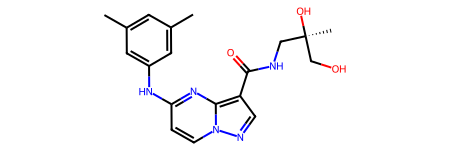

In [5]:
info['Mol']['rdmol']

The `MoleculesData` class contains four categories of information: `Mol`, `Dock`, `Score` (set to `None` if the model is not 3D in-situ), and `Prop`. These correspond to basic molecular information, docking (and rescoring) results, and molecular properties (excluding molecular distances), respectively.  

Each category further consists of more detailed fields. Using the following cells as examples, one can retrieve a list of a specific type of information for all molecules associated with this target.


In [ ]:
# Get all molecules
mols = tyk2.Mol.rdmol
mols

In [ ]:
# Get molecular weights
tyk2.Prop.descriptors['molwt']

[166.06299418,
 199.074561908,
 346.154209196,
 318.11867116,
 376.16232926800006,
 384.11437812,
 269.113982108,
 620.1990467200001,
 196.103419512,
 305.11642672000005,
 495.1794209,
 241.048741084,
 207.04509162,
 387.071133404,
 369.090053104,
 306.144038436,
 128.094963004,
 478.987271792,
 308.029474804,
 410.130028184,
 256.137576764,
 286.106590308,
 460.8822672139999,
 234.096854824,
 363.088687748,
 392.1066876239999,
 481.9270532179999,
 154.01222156,
 342.194342692,
 236.132491384,
 422.210661452,
 226.050905272,
 290.149123816,
 133.063997224,
 249.066889684,
 302.0822054,
 453.141259476,
 362.137890436,
 262.050905272,
 328.201159388,
 281.0775966,
 194.06914218,
 286.193280072,
 188.97481914,
 241.08849772,
 498.140508124,
 389.209025364,
 320.098334132,
 264.137496512,
 406.132885308,
 176.047344116,
 339.055169668,
 385.986761014,
 320.082874096,
 485.159611972,
 187.110947416,
 209.095297352,
 215.026854712,
 432.1716891000001,
 312.16985926,
 326.0822054,
 133.073893